In [1]:
from pathlib import Path

root = Path("data/cityscapes")

print("leftImg8bit exists:", (root / "leftImg8bit").exists())
print("gtFine exists:", (root / "gtFine").exists())

for split in ["train", "val", "test"]:
    print(f"{split} images:", (root / "leftImg8bit" / split).exists())
    print(f"{split} labels:", (root / "gtFine" / split).exists())

leftImg8bit exists: True
gtFine exists: True
train images: True
train labels: True
val images: True
val labels: True
test images: True
test labels: True


In [2]:
from pathlib import Path

root = Path("data/cityscapes")

for split in ["train", "val", "test"]:
    images = list((root / "leftImg8bit" / split).rglob("*_leftImg8bit.png"))
    labels = list((root / "gtFine" / split).rglob("*_gtFine_labelIds.png"))

    print(f"{split.upper()}:")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}")
    print("-" * 40)

TRAIN:
  Images : 2975
  Labels : 2975
----------------------------------------
VAL:
  Images : 500
  Labels : 500
----------------------------------------
TEST:
  Images : 1525
  Labels : 1525
----------------------------------------


In [3]:
from pathlib import Path

root = Path("data/cityscapes")

for split in ["train", "val", "test"]:
    city_dirs = sorted([p.name for p in (root / "leftImg8bit" / split).iterdir() if p.is_dir()])
    print(f"{split.upper()} - nombre de villes: {len(city_dirs)}")
    print(city_dirs)
    print("-" * 60)

TRAIN - nombre de villes: 18
['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt', 'dusseldorf', 'erfurt', 'hamburg', 'hanover', 'jena', 'krefeld', 'monchengladbach', 'strasbourg', 'stuttgart', 'tubingen', 'ulm', 'weimar', 'zurich']
------------------------------------------------------------
VAL - nombre de villes: 3
['frankfurt', 'lindau', 'munster']
------------------------------------------------------------
TEST - nombre de villes: 6
['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz', 'munich']
------------------------------------------------------------


Image path: data\cityscapes\leftImg8bit\train\aachen\aachen_000000_000019_leftImg8bit.png
Mask path : data\cityscapes\gtFine\train\aachen\aachen_000000_000019_gtFine_labelIds.png
Image shape: (1024, 2048, 3)
Mask shape : (1024, 2048)
Unique raw labels: [ 0  1  3  4  7  8 11 17 20 21 22 23 24 25 26 33]


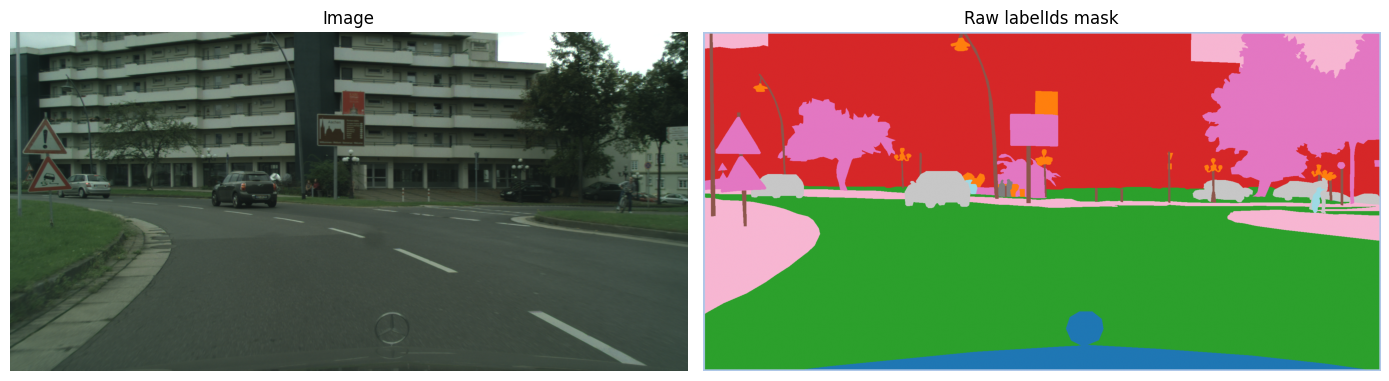

In [4]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

root = Path("data/cityscapes")

img_path = next((root / "leftImg8bit" / "train").rglob("*_leftImg8bit.png"))
relative = img_path.relative_to(root / "leftImg8bit" / "train")
mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
mask_path = root / "gtFine" / "train" / relative.parent / mask_name

image = np.array(Image.open(img_path).convert("RGB"))
mask = np.array(Image.open(mask_path))

print("Image path:", img_path)
print("Mask path :", mask_path)
print("Image shape:", image.shape)
print("Mask shape :", mask.shape)
print("Unique raw labels:", np.unique(mask))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab20")
plt.title("Raw labelIds mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Unique raw labels   : [ 0  1  3  4  7  8 11 17 20 21 22 23 24 25 26 33]
Unique mapped labels: [  0   1   2   5   7   8   9  10  11  12  13  18 255]


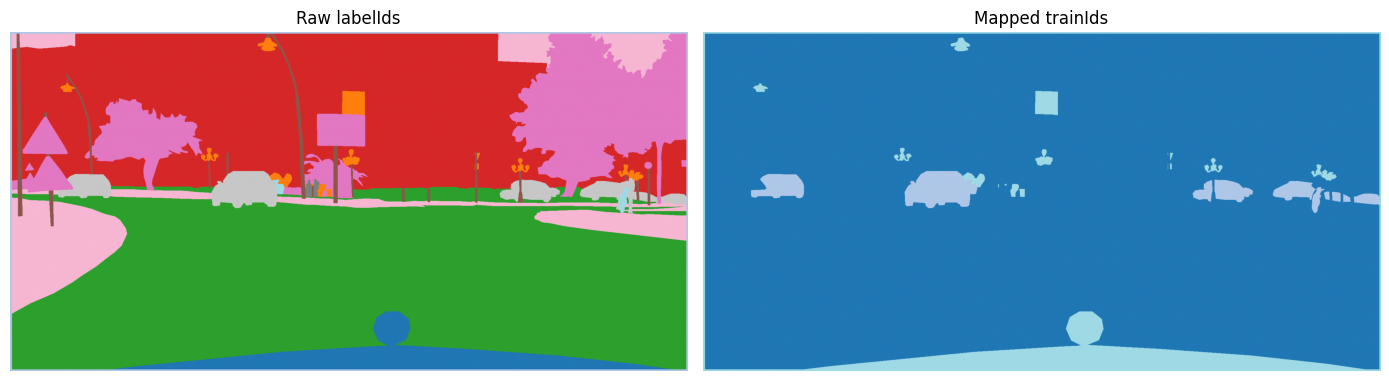

In [5]:
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

CITYSCAPES_ID_TO_TRAIN_ID = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255,
}

def encode_cityscapes_mask(mask):
    encoded = np.full(mask.shape, 255, dtype=np.uint8)
    for k, v in CITYSCAPES_ID_TO_TRAIN_ID.items():
        encoded[mask == k] = v
    return encoded

root = Path("data/cityscapes")
mask_path = next((root / "gtFine" / "train").rglob("*_gtFine_labelIds.png"))

raw_mask = np.array(Image.open(mask_path), dtype=np.int64)
train_mask = encode_cityscapes_mask(raw_mask)

print("Unique raw labels   :", np.unique(raw_mask))
print("Unique mapped labels:", np.unique(train_mask))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(raw_mask, cmap="tab20")
plt.title("Raw labelIds")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(train_mask, cmap="tab20")
plt.title("Mapped trainIds")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from pathlib import Path
from PIL import Image
import numpy as np

root = Path("data/cityscapes")
img_files = list((root / "leftImg8bit" / "train").rglob("*_leftImg8bit.png"))

sizes = []
for p in img_files[:200]:
    with Image.open(p) as im:
        sizes.append(im.size)

sizes = np.array(sizes)
print("Largeurs uniques:", np.unique(sizes[:, 0]))
print("Hauteurs uniques:", np.unique(sizes[:, 1]))
print("Taille moyenne (w,h):", sizes.mean(axis=0))

Largeurs uniques: [2048]
Hauteurs uniques: [1024]
Taille moyenne (w,h): [2048. 1024.]


Distribution approximative des classes:
 0 - road           : 139937886
 1 - sidewalk       : 21961631
 2 - building       : 94756427
 3 - wall           : 1739038
 4 - fence          : 1371092
 5 - pole           : 4218387
 6 - traffic_light  : 834897
 7 - traffic_sign   : 2277125
 8 - vegetation     : 63349064
 9 - terrain        : 5098357
10 - sky            : 11210034
11 - person         : 3730147
12 - rider          : 203960
13 - car            : 26332995
14 - truck          : 445411
15 - bus            : 836675
16 - train          : 18131
17 - motorcycle     : 445920
18 - bicycle        : 1040342


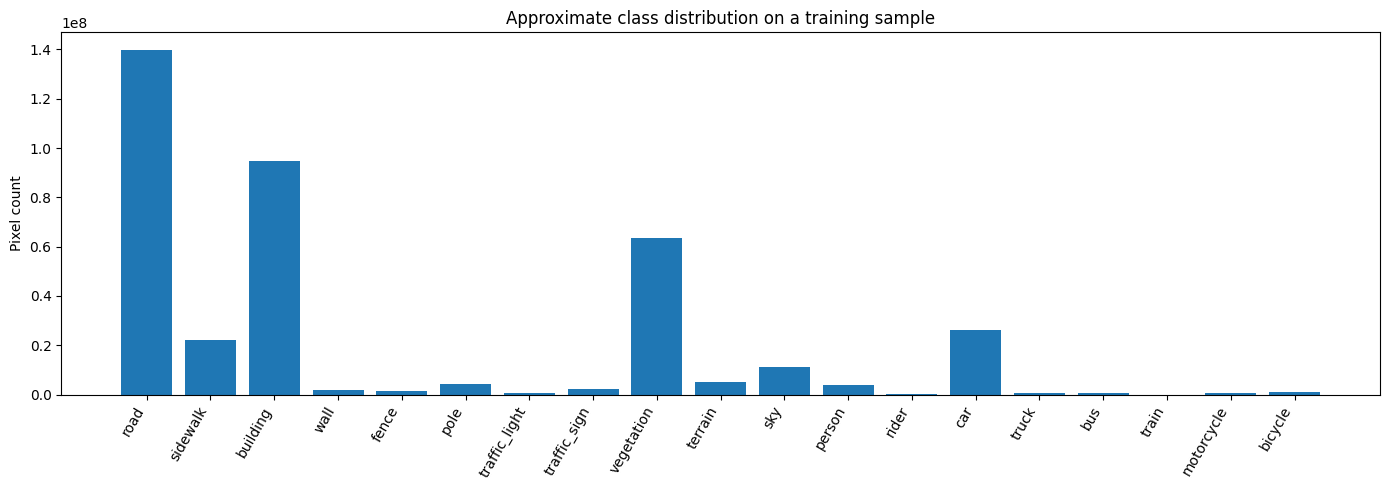

In [9]:
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic_light", "traffic_sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train",
    "motorcycle", "bicycle"
]

counter = Counter()
mask_files = list((root / "gtFine" / "train").rglob("*_gtFine_labelIds.png"))

for p in mask_files[:200]:
    raw_mask = np.array(Image.open(p), dtype=np.int64)
    mapped = encode_cityscapes_mask(raw_mask)
    vals, counts = np.unique(mapped, return_counts=True)
    for v, c in zip(vals, counts):
        if v != 255:
            counter[int(v)] += int(c)

print("Distribution approximative des classes:")
for class_id, class_name in enumerate(CITYSCAPES_CLASSES):
    print(f"{class_id:2d} - {class_name:15s}: {counter[class_id]}")

class_counts = [counter[i] for i in range(len(CITYSCAPES_CLASSES))]

plt.figure(figsize=(14, 5))
plt.bar(CITYSCAPES_CLASSES, class_counts)
plt.xticks(rotation=60, ha="right")
plt.title("Approximate class distribution on a training sample")
plt.ylabel("Pixel count")
plt.tight_layout()
plt.show()

In [10]:
import sys
from pathlib import Path
sys.path.append(str(Path("src").resolve()))

from dataset import CityscapesSegmentation, JointTransform

train_dataset = CityscapesSegmentation(
    root="data/cityscapes",
    split="train",
    transform=JointTransform(image_size=(256, 512), train=True)
)

val_dataset = CityscapesSegmentation(
    root="data/cityscapes",
    split="val",
    transform=JointTransform(image_size=(256, 512), train=False)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

image, mask = train_dataset[0]
print("Image tensor shape:", image.shape)
print("Mask tensor shape :", mask.shape)
print("Mask unique values:", np.unique(mask.numpy()))

Train size: 2975
Val size: 500
Image tensor shape: torch.Size([3, 256, 512])
Mask tensor shape : torch.Size([256, 512])
Mask unique values: [  0   1   2   5   7   8   9  10  11  12  13  18 255]


Images batch: torch.Size([4, 3, 256, 512])
Masks batch : torch.Size([4, 256, 512])


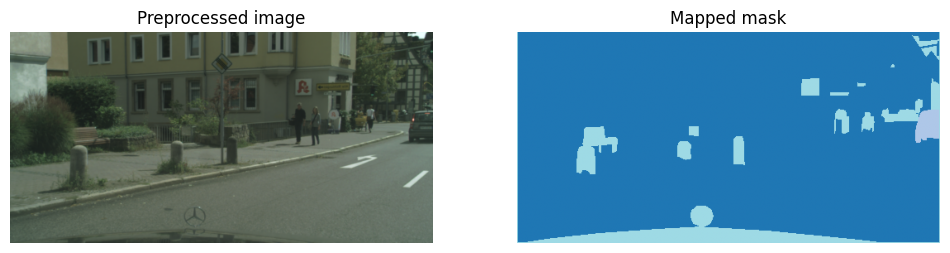

In [11]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
images, masks = next(iter(train_loader))

print("Images batch:", images.shape)
print("Masks batch :", masks.shape)

img = images[0].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Preprocessed image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0].numpy(), cmap="tab20")
plt.title("Mapped mask")
plt.axis("off")
plt.show()

In [20]:
import sys
from pathlib import Path
import importlib

sys.path.append(str(Path("src").resolve()))

import model_unet
importlib.reload(model_unet)

from model_unet import UNetBaseline

model = UNetBaseline(num_classes=19)
print(model)

UNetBaseline(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

In [21]:
import torch
from model_unet import UNetBaseline

model = UNetBaseline(num_classes=19)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 31,038,803
Trainable parameters : 31,038,803


In [23]:
import torch
from model_unet import UNetBaseline

model = UNetBaseline(num_classes=19)
x = torch.randn(1, 3, 256, 512)

with torch.no_grad():
    x1 = model.inc(x)
    x2 = model.down1(x1)
    x3 = model.down2(x2)
    x4 = model.down3(x3)
    x5 = model.down4(x4)

    d1 = model.up1(x5, x4)
    d2 = model.up2(d1, x3)
    d3 = model.up3(d2, x2)
    d4 = model.up4(d3, x1)
    out = model.outc(d4)

print("Input :", x.shape)
print("x1    :", x1.shape)
print("x2    :", x2.shape)
print("x3    :", x3.shape)
print("x4    :", x4.shape)
print("x5    :", x5.shape)
print("d1    :", d1.shape)
print("d2    :", d2.shape)
print("d3    :", d3.shape)
print("d4    :", d4.shape)
print("Output:", out.shape)

Input : torch.Size([1, 3, 256, 512])
x1    : torch.Size([1, 64, 256, 512])
x2    : torch.Size([1, 128, 128, 256])
x3    : torch.Size([1, 256, 64, 128])
x4    : torch.Size([1, 512, 32, 64])
x5    : torch.Size([1, 1024, 16, 32])
d1    : torch.Size([1, 512, 32, 64])
d2    : torch.Size([1, 256, 64, 128])
d3    : torch.Size([1, 128, 128, 256])
d4    : torch.Size([1, 64, 256, 512])
Output: torch.Size([1, 19, 256, 512])


In [24]:
import torch
from model_unet import UNetBaseline

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetBaseline(num_classes=19).to(device)
checkpoint = torch.load("checkpoints/unet_baseline_best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best mIoU:", checkpoint.get("best_miou", "N/A"))

Best mIoU: 0.28427213430404663


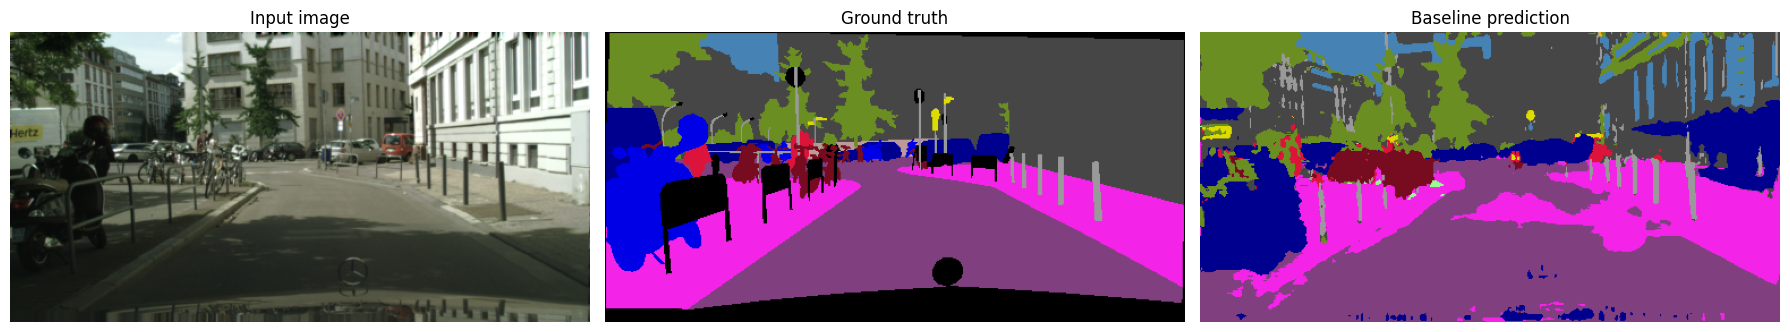

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

CITYSCAPES_COLORS = np.array([
    [128,  64, 128],
    [244,  35, 232],
    [ 70,  70,  70],
    [102, 102, 156],
    [190, 153, 153],
    [153, 153, 153],
    [250, 170,  30],
    [220, 220,   0],
    [107, 142,  35],
    [152, 251, 152],
    [ 70, 130, 180],
    [220,  20,  60],
    [255,   0,   0],
    [  0,   0, 142],
    [  0,   0,  70],
    [  0,  60, 100],
    [  0,  80, 100],
    [  0,   0, 230],
    [119,  11,  32],
], dtype=np.uint8)

def denormalize_image(image_tensor):
    image = image_tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = np.clip(image * std + mean, 0, 1)
    return image

def decode_segmentation(mask, colors=CITYSCAPES_COLORS, ignore_index=255):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id in range(len(colors)):
        color_mask[mask == class_id] = colors[class_id]
    color_mask[mask == ignore_index] = [0, 0, 0]
    return color_mask

val_dataset = CityscapesSegmentation(
    root="data/cityscapes",
    split="val",
    transform=JointTransform(image_size=(256, 512), train=False)
)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True, num_workers=0)

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    preds = torch.argmax(logits, dim=1)

image_np = denormalize_image(images[0])
gt_color = decode_segmentation(masks[0].numpy())
pred_color = decode_segmentation(preds[0].cpu().numpy())

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_color)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_color)
plt.title("Baseline prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
import torch
from torch.utils.data import DataLoader

import metrics
importlib.reload(metrics)

from metrics import compute_confusion_matrix, compute_iou_from_confmat, pixel_accuracy

val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

total_confmat = torch.zeros((19, 19), dtype=torch.int64, device=device)
acc_list = []

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        total_confmat += compute_confusion_matrix(preds, masks, num_classes=19, ignore_index=255)
        acc_list.append(pixel_accuracy(preds, masks, ignore_index=255))

iou_per_class, miou = compute_iou_from_confmat(total_confmat)
avg_acc = sum(acc_list) / len(acc_list)

print("Validation Pixel Accuracy:", avg_acc)
print("Validation mIoU:", miou)

Validation Pixel Accuracy: 0.8223722627028406
Validation mIoU: 0.28427213430404663


In [29]:
CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic_light", "traffic_sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train",
    "motorcycle", "bicycle"
]

for cls, iou in zip(CITYSCAPES_CLASSES, iou_per_class):
    print(f"{cls:15s}: {iou:.4f}")

road           : 0.9243
sidewalk       : 0.5093
building       : 0.6273
wall           : 0.0032
fence          : 0.0004
pole           : 0.2070
traffic_light  : 0.0327
traffic_sign   : 0.1778
vegetation     : 0.7535
terrain        : 0.3457
sky            : 0.5780
person         : 0.2462
rider          : 0.0000
car            : 0.6945
truck          : 0.0000
bus            : 0.0001
train          : 0.0000
motorcycle     : 0.0000
bicycle        : 0.3010


In [30]:
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

In [31]:
plt.savefig("figures/raw_image_mask.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/baseline_prediction.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>